# INF8239_U01 — Ensambles, reducción dimensional y Green AI

## U01.LAB03 — Ensambles, reducción dimensional y Green AI

**Estudiante:** Laudys Jerusi Zapata  
**Programa:** Maestría en Ciencia de Datos e Inteligencia Artificial  
**Institución:** Universidad Autónoma de Santo Domingo (UASD)  
**Asignatura:** INF8239 — Ciencia de Datos II  
**Maestro:** Edwin Ramón José Nolasco  
**Unidad:** U01 — Modelos avanzados, reducción dimensional y Green AI  
**Práctica:** LAB03 — Ejercicio 02

### Pregunta de investigación

¿Es posible clasificar los centros educativos de la República Dominicana según su nivel de promoción académica en las Pruebas Nacionales del período 2024, utilizando información disponible sobre sus características generales, mediante modelos de clasificación y comparando su rendimiento con el costo computacional?

### Objetivo

Comparar diferentes configuraciones de modelos de clasificación, incluyendo SVM, Random Forest y boosting, incorporando reducción dimensional mediante PCA y análisis exploratorio con t-SNE, para estudiar el equilibrio entre rendimiento predictivo y costo computacional bajo un enfoque de Green AI.

### Protocolo de evaluación

Se mantiene el mismo dataset, período, variable objetivo, exclusiones de variables y partición entrenamiento/prueba definidos en LAB02. El conjunto de prueba permanece reservado hasta la evaluación final de los modelos.

**Métrica primaria:** F1 macro.  
**Métrica secundaria:** Recall macro.  
**Clase prioritaria de análisis:** clase 1 — centros con nivel de promoción alto respecto al punto de corte establecido en LAB02.

## 1. Protocolo congelado de LAB02

Para garantizar una comparación justa entre los modelos, LAB03 mantiene sin modificaciones las decisiones metodológicas establecidas en LAB02.

- **Dataset:** Pruebas Nacionales de la República Dominicana, período 2016–2024.
- **Período analizado:** 2024.
- **Unidad de análisis:** centro educativo.
- **Variable objetivo:** `target_promocion`.
- **Construcción del objetivo:** se utiliza como punto de corte la mediana de la `tasa_promocion`.
- **Punto de corte establecido en LAB02:** 0.8037.
- **Clases:** 0 = nivel de promoción inferior al punto de corte; 1 = nivel de promoción igual o superior al punto de corte.
- **Predictores conservados:** `Regional`, `Distrito`, `Nivel/Modalidad` y `Cantidad de estudiantes`.
- **Variables excluidas:** variables de identificación, período, convocatoria, resultados académicos de las áreas evaluadas y variables utilizadas para construir o derivar directamente el resultado objetivo.
- **Partición:** 80 % entrenamiento y 20 % prueba.
- **Semilla:** `random_state=42`.
- **Estratificación:** sí, mediante `stratify=y`.
- **Conjunto de prueba:** permanece reservado para la evaluación de los modelos.
- **Métrica primaria:** F1 macro.
- **Métrica secundaria:** Recall macro.
- **Clase prioritaria:** clase 1, correspondiente a centros con nivel de promoción alto respecto al punto de corte.

La finalidad de este congelamiento es evitar cambiar las condiciones experimentales para favorecer un modelo específico y permitir una comparación reproducible entre las configuraciones evaluadas.

In [1]:
# ============================================================
# IMPORTACIONES Y ENTORNO
# MANDATO LAB03:
# Importar las librerías necesarias y registrar el entorno
# computacional utilizado en los experimentos.
# ============================================================

from pathlib import Path
from time import perf_counter
import platform
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)
from sklearn.svm import SVC

print("Python:", sys.version)
print("Sistema:", platform.platform())
print("Procesador:", platform.processor())
print("scikit-learn:", __import__("sklearn").__version__)

Python: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
Sistema: Windows-11-10.0.26200-SP0
Procesador: Intel64 Family 6 Model 141 Stepping 1, GenuineIntel
scikit-learn: 1.9.1


In [2]:
# ============================================================
# CARGAR Y VERIFICAR EL DATASET
# MANDATO LAB03:
# Reutilizar el mismo dataset definido en LAB02.
# Verificar la estructura y dimensiones antes del análisis.
# ============================================================

DATA_PATH = Path("../data/raw/pruebas_nacionales_2016_2024.csv")

df = pd.read_csv(
    DATA_PATH,
    sep=";",
    encoding="latin1"
)

print("Dimensiones del dataset:", df.shape)

print("\nColumnas:")
print(df.columns.tolist())

Dimensiones del dataset: (57586, 16)

Columnas:
['Período', 'Convocatoria', 'Regional', 'Distrito', 'Nivel/Modalidad', 'Código de Centro', 'Nombre de Centro', 'Español', 'Matemáticas', 'Sociales', 'Naturales', 'Cantidad de estudiantes', 'Cantidad Femenino', 'Cantidad masculino', 'Cantidad Promovidos', 'Cantidad Aplazados']


In [3]:
# ============================================================
# SELECCIONAR EL PERÍODO 2024
# MANDATO LAB03:
# Mantener el mismo período definido en LAB02.
# El análisis se realiza exclusivamente con los datos
# correspondientes al período 2024.
# ============================================================

df_2024 = df[df["Período"] == 2024].copy()

print("Dimensiones de los datos de 2024:", df_2024.shape)

print("\nPeríodos presentes:")
print(df_2024["Período"].value_counts().sort_index())

Dimensiones de los datos de 2024: (3474, 16)

Períodos presentes:
Período
2024    3474
Name: count, dtype: int64


In [4]:
# ============================================================
# CONGELAR Y VERIFICAR LA VARIABLE OBJETIVO
# MANDATO LAB03:
# Reutilizar exactamente la variable objetivo definida
# en LAB02 sin modificar su construcción.
# ============================================================

TARGET = "target_promocion"

df_2024["tasa_promocion"] = (
    df_2024["Cantidad Promovidos"]
    / df_2024["Cantidad de estudiantes"]
)

punto_corte = df_2024["tasa_promocion"].median()

df_2024[TARGET] = (
    df_2024["tasa_promocion"] >= punto_corte
).astype(int)

print("Variable objetivo:", TARGET)
print("Punto de corte:", round(punto_corte, 4))

print("\nDistribución de clases:")
print(df_2024[TARGET].value_counts().sort_index())

print("\nProporción de clases:")
print(
    df_2024[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Variable objetivo: target_promocion
Punto de corte: 0.8037

Distribución de clases:
target_promocion
0    1737
1    1737
Name: count, dtype: int64

Proporción de clases:
target_promocion
0    0.5
1    0.5
Name: proportion, dtype: float64


In [5]:
# ============================================================
# CONGELAR LAS VARIABLES PREDICTORAS
# MANDATO LAB03:
# Reutilizar exactamente las exclusiones definidas en LAB02.
# No utilizar variables que construyen directamente el objetivo
# ni variables derivadas del resultado final.
# ============================================================

DROP_COLUMNS = [
    "Período",
    "Convocatoria",
    "Código de Centro",
    "Nombre de Centro",
    "Cantidad Promovidos",
    "Cantidad Aplazados",
    "Cantidad Femenino",
    "Cantidad masculino",
    "Español",
    "Matemáticas",
    "Sociales",
    "Naturales",
    "tasa_promocion"
]

print("Variables excluidas:")
print(DROP_COLUMNS)

print("\nCantidad de variables excluidas:", len(DROP_COLUMNS))

Variables excluidas:
['Período', 'Convocatoria', 'Código de Centro', 'Nombre de Centro', 'Cantidad Promovidos', 'Cantidad Aplazados', 'Cantidad Femenino', 'Cantidad masculino', 'Español', 'Matemáticas', 'Sociales', 'Naturales', 'tasa_promocion']

Cantidad de variables excluidas: 13


In [6]:
# ============================================================
# EXCLUSIÓN DE VARIABLES Y PREVENCIÓN DE LEAKAGE
# MANDATO LAB03:
# Mantener exactamente las exclusiones establecidas en LAB02.
# No utilizar variables que construyen directamente el target,
# variables derivadas del resultado final ni identificadores
# como predictores.
# ============================================================

DROP_COLUMNS = [
    "Período",
    "Convocatoria",
    "Código de Centro",
    "Nombre de Centro",
    "Cantidad Promovidos",
    "Cantidad Aplazados",
    "Cantidad Femenino",
    "Cantidad masculino",
    "Español",
    "Matemáticas",
    "Sociales",
    "Naturales",
    "tasa_promocion",
]

X = df_2024.drop(columns=[TARGET] + DROP_COLUMNS)
y = df_2024[TARGET]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variables predictoras:
['Regional', 'Distrito', 'Nivel/Modalidad', 'Cantidad de estudiantes']

Dimensiones de X: (3474, 4)
Dimensiones de y: (3474,)


In [7]:
# ============================================================
# CONSTRUIR X E Y
# MANDATO LAB03:
# Construir la matriz de variables predictoras X y la variable
# objetivo y utilizando exactamente las variables congeladas.
# ============================================================

X = df_2024.drop(
    columns=[TARGET] + DROP_COLUMNS
)

y = df_2024[TARGET]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nVariables predictoras:")
print(X.columns.tolist())

print("\nDistribución de la variable objetivo:")
print(y.value_counts().sort_index())

Dimensiones de X: (3474, 4)
Dimensiones de y: (3474,)

Variables predictoras:
['Regional', 'Distrito', 'Nivel/Modalidad', 'Cantidad de estudiantes']

Distribución de la variable objetivo:
target_promocion
0    1737
1    1737
Name: count, dtype: int64


In [8]:
# ============================================================
# PARTICIÓN ENTRENAMIENTO/PRUEBA
# MANDATO LAB03:
# Mantener exactamente la partición de LAB02:
# 80 % entrenamiento, 20 % prueba, random_state=42
# y estratificación por la variable objetivo.
# ============================================================

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", Xtr.shape)
print("Prueba:", Xte.shape)

print("\nDistribución de clases en entrenamiento:")
print(ytr.value_counts(normalize=True).sort_index().round(4))

print("\nDistribución de clases en prueba:")
print(yte.value_counts(normalize=True).sort_index().round(4))

Entrenamiento: (2779, 4)
Prueba: (695, 4)

Distribución de clases en entrenamiento:
target_promocion
0    0.4998
1    0.5002
Name: proportion, dtype: float64

Distribución de clases en prueba:
target_promocion
0    0.5007
1    0.4993
Name: proportion, dtype: float64


In [9]:
# ============================================================
# PREPROCESAMIENTO
# MANDATO LAB03:
# Reutilizar el preprocesamiento definido en LAB02 y preparar
# una versión densa para los modelos que requieren matrices
# densas, especialmente boosting y PCA.
# ============================================================

num_cols = [
    "Cantidad de estudiantes"
]

cat_cols = [
    "Regional",
    "Distrito",
    "Nivel/Modalidad"
]

# ------------------------------------------------------------
# PREPROCESAMIENTO ORIGINAL DEL LAB02
# ------------------------------------------------------------

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

# ------------------------------------------------------------
# PREPROCESAMIENTO DENSO PARA BOOSTING Y PCA
# ------------------------------------------------------------

cat_pipe_dense = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocess_dense = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe_dense, cat_cols)
])

print("Variables numéricas:")
print(num_cols)

print("\nVariables categóricas:")
print(cat_cols)

print("\nPreprocesamiento original: listo")
print("Preprocesamiento denso para boosting y PCA: listo")

Variables numéricas:
['Cantidad de estudiantes']

Variables categóricas:
['Regional', 'Distrito', 'Nivel/Modalidad']

Preprocesamiento original: listo
Preprocesamiento denso para boosting y PCA: listo


In [10]:
# ============================================================
# PARTICIÓN DE ENTRENAMIENTO Y PRUEBA
# MANDATO LAB03:
# Reutilizar exactamente la partición definida en LAB02:
# 80% entrenamiento, 20% prueba, random_state=42 y
# estratificación de la variable objetivo.
# El conjunto de prueba queda reservado.
# ============================================================

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensiones de Xtr:", Xtr.shape)
print("Dimensiones de Xte:", Xte.shape)

print("\nDimensiones de ytr:", ytr.shape)
print("Dimensiones de yte:", yte.shape)

print("\nDistribución de clases en entrenamiento:")
print(ytr.value_counts(normalize=True).sort_index().round(4))

print("\nDistribución de clases en prueba:")
print(yte.value_counts(normalize=True).sort_index().round(4))

Dimensiones de Xtr: (2779, 4)
Dimensiones de Xte: (695, 4)

Dimensiones de ytr: (2779,)
Dimensiones de yte: (695,)

Distribución de clases en entrenamiento:
target_promocion
0    0.4998
1    0.5002
Name: proportion, dtype: float64

Distribución de clases en prueba:
target_promocion
0    0.5007
1    0.4993
Name: proportion, dtype: float64


In [11]:
# ============================================================
# CATÁLOGO DE MODELOS
# MANDATO LAB03:
# Construir un catálogo de modelos para comparar diferentes
# familias de aprendizaje supervisado bajo el mismo protocolo.
#
# Configuraciones:
# 1. Regresión logística
# 2. SVM con C=1
# 3. SVM con C=10
# 4. Random Forest con 100 árboles
# 5. Random Forest con 300 árboles
# 6. HistGradientBoosting
# ============================================================

models = {
    "logistic": Pipeline([
        ("prep", preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]),

    "svm_c1": Pipeline([
        ("prep", preprocess),
        (
            "model",
            SVC(
                C=1,
                probability=True,
                random_state=42
            )
        )
    ]),

    "svm_c10": Pipeline([
        ("prep", preprocess),
        (
            "model",
            SVC(
                C=10,
                probability=True,
                random_state=42
            )
        )
    ]),

    "rf_100": Pipeline([
        ("prep", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "rf_300": Pipeline([
        ("prep", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "boost": Pipeline([
        ("prep", preprocess_dense),
        (
            "model",
            HistGradientBoostingClassifier(
                max_depth=6,
                random_state=42
            )
        )
    ])
}

print("Modelos definidos:")
for name in models:
    print("-", name)

print("\nCantidad total de configuraciones:", len(models))


Modelos definidos:
- logistic
- svm_c1
- svm_c10
- rf_100
- rf_300
- boost

Cantidad total de configuraciones: 6


In [12]:
# ============================================================
# MEDIR RENDIMIENTO Y COSTO COMPUTACIONAL
# MANDATO LAB03:
# Medir cada modelo 3 veces y registrar:
# - F1 macro
# - Recall macro
# - Mediana del tiempo de ajuste
# - Tiempo de predicción
# - Tamaño del modelo serializado
# ============================================================

Path("reports/models").mkdir(
    parents=True,
    exist_ok=True
)

rows = []

for name, model in models.items():

    fit_times = []

    # --------------------------------------------------------
    # MEDICIÓN DEL AJUSTE: 3 REPETICIONES
    # --------------------------------------------------------

    for repetition in range(3):

        start = perf_counter()

        model.fit(Xtr, ytr)

        elapsed = perf_counter() - start

        fit_times.append(elapsed)

    # --------------------------------------------------------
    # MEDICIÓN DE PREDICCIÓN
    # --------------------------------------------------------

    start = perf_counter()

    pred = model.predict(Xte)

    predict_ms = (
        perf_counter() - start
    ) * 1000

    # --------------------------------------------------------
    # SERIALIZACIÓN DEL MODELO
    # --------------------------------------------------------

    path = (
        Path("reports/models")
        / f"{name}.joblib"
    )

    joblib.dump(
        model,
        path
    )

    # --------------------------------------------------------
    # MÉTRICAS
    # --------------------------------------------------------

    f1_macro = f1_score(
        yte,
        pred,
        average="macro"
    )

    recall_macro = recall_score(
        yte,
        pred,
        average="macro"
    )

    # --------------------------------------------------------
    # GUARDAR RESULTADOS
    # --------------------------------------------------------

    rows.append({
        "model": name,
        "f1_macro": f1_macro,
        "recall_macro": recall_macro,
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

# ------------------------------------------------------------
# TABLA FINAL DE RESULTADOS
# ------------------------------------------------------------

results = pd.DataFrame(rows)

results = results.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

print("RESULTADOS DE LOS MODELOS")
print("=" * 70)

print(
    results.round({
        "f1_macro": 4,
        "recall_macro": 4,
        "fit_median_s": 4,
        "predict_ms": 4,
        "size_kb": 2
    }).to_string(index=False)
)

C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The

RESULTADOS DE LOS MODELOS
   model  f1_macro  recall_macro  fit_median_s  predict_ms  size_kb
  rf_300    0.6362        0.6415        0.3856     62.3142  2694.54
logistic    0.6355        0.6359        0.0630      6.4946     5.92
  rf_100    0.6338        0.6387        0.1482     30.8659   879.23
   boost    0.6319        0.6330        0.2297      6.4333   211.97
  svm_c1    0.6182        0.6187        0.8565     43.9721   188.57
 svm_c10    0.6129        0.6129        0.9113     30.8067   171.08


In [13]:
# ============================================================
# GUARDAR RESULTADOS EXPERIMENTALES
# MANDATO LAB03:
# Guardar los resultados de rendimiento y costo computacional
# para garantizar trazabilidad y reproducibilidad del análisis.
# ============================================================

RESULTS_PATH = Path(
    "reports/green_ai_results.csv"
)

results.to_csv(
    RESULTS_PATH,
    index=False
)

print("Archivo guardado:")
print(RESULTS_PATH)

print("\nNúmero de modelos registrados:", len(results))

print("\nColumnas del archivo:")
print(results.columns.tolist())

Archivo guardado:
reports\green_ai_results.csv

Número de modelos registrados: 6

Columnas del archivo:
['model', 'f1_macro', 'recall_macro', 'fit_median_s', 'predict_ms', 'size_kb']


In [14]:
# ============================================================
# CONFIGURAR SVM CON PCA
# MANDATO LAB03:
# Incorporar reducción dimensional mediante PCA y comparar
# posteriormente el SVM C=1 con y sin reducción dimensional.
# ============================================================

svm_pca = Pipeline([
    ("prep", preprocess_dense),

    # Estandarización de todas las variables transformadas
    ("scale_all", StandardScaler()),

    # Conservamos el 95% de la varianza
    ("pca", PCA(
        n_components=0.95,
        random_state=42
    )),

    # Mismo SVM utilizado como referencia
    ("model", SVC(
        C=1,
        probability=True,
        random_state=42
    ))
])

print("Pipeline SVM + PCA creado correctamente.")
print("\nPasos del pipeline:")
for name, step in svm_pca.steps:
    print("-", name)

Pipeline SVM + PCA creado correctamente.

Pasos del pipeline:
- prep
- scale_all
- pca
- model


In [15]:
# ============================================================
# MEDIR LA REDUCCIÓN DIMENSIONAL CON PCA
# MANDATO LAB03:
# Medir las dimensiones antes y después de PCA y verificar
# qué proporción de varianza se conserva.
# ============================================================

# Transformar únicamente con el preprocesamiento
Xtr_dense = preprocess_dense.fit_transform(Xtr)

# Aplicar la estandarización previa al PCA
Xtr_scaled = StandardScaler().fit_transform(Xtr_dense)

# Ajustar PCA conservando el 95% de la varianza
pca_check = PCA(
    n_components=0.95,
    random_state=42
)

Xtr_pca = pca_check.fit_transform(Xtr_scaled)

print("Dimensiones antes de PCA:", Xtr_scaled.shape)
print("Dimensiones después de PCA:", Xtr_pca.shape)

print(
    "\nNúmero de componentes seleccionados:",
    pca_check.n_components_
)

print(
    "Varianza explicada acumulada:",
    round(
        pca_check.explained_variance_ratio_.sum(),
        4
    )
)

Dimensiones antes de PCA: (2779, 146)
Dimensiones después de PCA: (2779, 118)

Número de componentes seleccionados: 118
Varianza explicada acumulada: 0.9528


In [16]:
# ============================================================
# COMPARAR SVM CON Y SIN PCA
# MANDATO LAB03:
# Comparar el SVM C=1 original con la versión que incorpora
# PCA, utilizando la misma partición de entrenamiento y prueba.
# ============================================================

# ------------------------------------------------------------
# SVM C=1 SIN PCA
# ------------------------------------------------------------

svm_sin_pca = models["svm_c1"]

start = perf_counter()

svm_sin_pca.fit(Xtr, ytr)

fit_sin_pca = perf_counter() - start

start = perf_counter()

pred_sin_pca = svm_sin_pca.predict(Xte)

predict_sin_pca = (
    perf_counter() - start
) * 1000

f1_sin_pca = f1_score(
    yte,
    pred_sin_pca,
    average="macro"
)

recall_sin_pca = recall_score(
    yte,
    pred_sin_pca,
    average="macro"
)

# ------------------------------------------------------------
# SVM C=1 CON PCA
# ------------------------------------------------------------

start = perf_counter()

svm_pca.fit(Xtr, ytr)

fit_con_pca = perf_counter() - start

start = perf_counter()

pred_con_pca = svm_pca.predict(Xte)

predict_con_pca = (
    perf_counter() - start
) * 1000

f1_con_pca = f1_score(
    yte,
    pred_con_pca,
    average="macro"
)

recall_con_pca = recall_score(
    yte,
    pred_con_pca,
    average="macro"
)

# ------------------------------------------------------------
# TABLA COMPARATIVA
# ------------------------------------------------------------

pca_results = pd.DataFrame([
    {
        "model": "SVM C=1 sin PCA",
        "f1_macro": f1_sin_pca,
        "recall_macro": recall_sin_pca,
        "fit_s": fit_sin_pca,
        "predict_ms": predict_sin_pca
    },
    {
        "model": "SVM C=1 con PCA",
        "f1_macro": f1_con_pca,
        "recall_macro": recall_con_pca,
        "fit_s": fit_con_pca,
        "predict_ms": predict_con_pca
    }
])

print("COMPARACIÓN SVM CON Y SIN PCA")
print("=" * 70)

print(
    pca_results.round({
        "f1_macro": 4,
        "recall_macro": 4,
        "fit_s": 4,
        "predict_ms": 4
    }).to_string(index=False)
)

C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\laudys.zapata\INF8239_U01_LAB03\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


COMPARACIÓN SVM CON Y SIN PCA
          model  f1_macro  recall_macro  fit_s  predict_ms
SVM C=1 sin PCA    0.6182        0.6187 0.8567     32.8197
SVM C=1 con PCA    0.5934        0.5942 1.7431    127.9482


In [17]:
# ============================================================
# PREPARAR DATOS PARA t-SNE
# MANDATO LAB03:
# Preparar una representación numérica de los predictores
# permitidos para realizar visualización exploratoria mediante
# t-SNE sin utilizar variables excluidas por fuga de información.
# ============================================================

X_num = X.select_dtypes(
    include="number"
).copy()

X_num = X_num.fillna(
    X_num.median()
)

sample = X_num.sample(
    n=min(1000, len(X_num)),
    random_state=42
)

y_sample = y.loc[
    sample.index
]

scaled = StandardScaler().fit_transform(
    sample
)

print("Variables numéricas utilizadas:")
print(X_num.columns.tolist())

print("\nDimensiones de la muestra:")
print(sample.shape)

print("\nDimensiones después de estandarizar:")
print(scaled.shape)

print("\nDistribución de clases en la muestra:")
print(y_sample.value_counts().sort_index())

Variables numéricas utilizadas:
['Regional', 'Distrito', 'Cantidad de estudiantes']

Dimensiones de la muestra:
(1000, 3)

Dimensiones después de estandarizar:
(1000, 3)

Distribución de clases en la muestra:
target_promocion
0    508
1    492
Name: count, dtype: int64


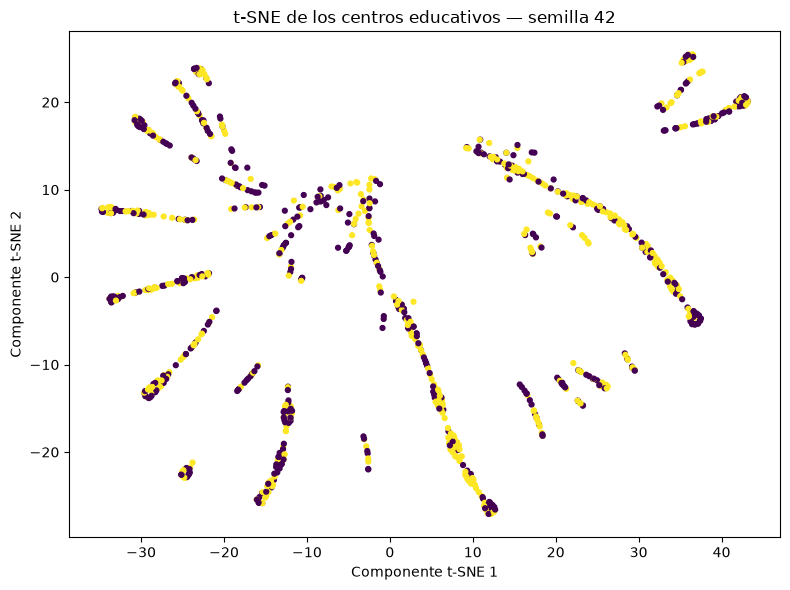

t-SNE con semilla 42 completado.
Dimensiones de la representación: (1000, 2)
Archivo guardado: reports/tsne_seed_42.png


In [18]:
# ============================================================
# t-SNE CON SEMILLA 42
# MANDATO LAB03:
# Generar una representación bidimensional mediante t-SNE
# utilizando la muestra preparada y la semilla 42.
# La visualización es exploratoria y no modifica el modelo.
# ============================================================

tsne_42 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca",
    learning_rate="auto"
)

embedding_42 = tsne_42.fit_transform(
    scaled
)

plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_42[:, 0],
    embedding_42[:, 1],
    c=pd.Categorical(y_sample).codes,
    s=12
)

plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.title("t-SNE de los centros educativos — semilla 42")

plt.tight_layout()

plt.savefig(
    "reports/tsne_seed_42.png",
    dpi=160
)

plt.show()

print("t-SNE con semilla 42 completado.")
print("Dimensiones de la representación:", embedding_42.shape)
print("Archivo guardado: reports/tsne_seed_42.png")

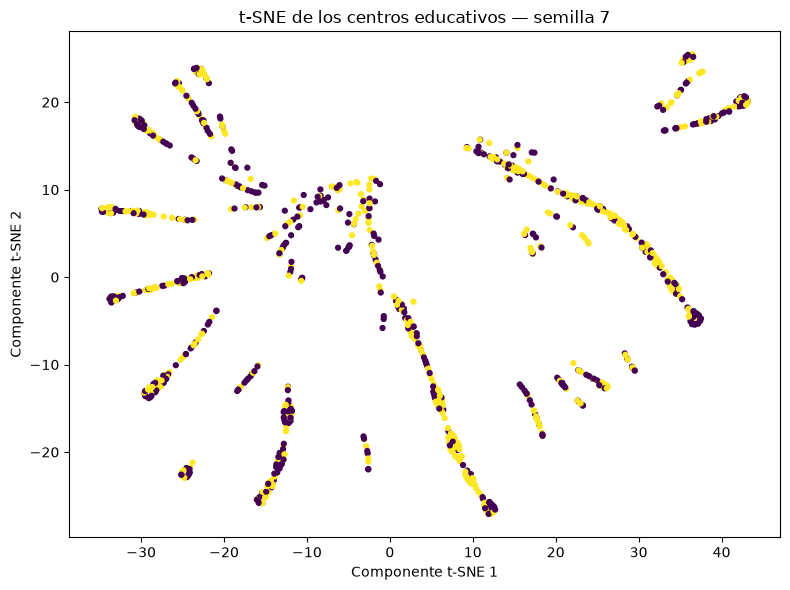

t-SNE con semilla 7 completado.
Dimensiones de la representación: (1000, 2)
Archivo guardado: reports/tsne_seed_7.png


In [19]:
# ============================================================
# t-SNE CON SEMILLA 7
# MANDATO LAB03:
# Generar una segunda representación bidimensional mediante
# t-SNE utilizando la misma muestra, las mismas variables y
# los mismos parámetros, cambiando únicamente la semilla.
# ============================================================

tsne_7 = TSNE(
    n_components=2,
    perplexity=30,
    random_state=7,
    init="pca",
    learning_rate="auto"
)

embedding_7 = tsne_7.fit_transform(
    scaled
)

plt.figure(figsize=(8, 6))

plt.scatter(
    embedding_7[:, 0],
    embedding_7[:, 1],
    c=pd.Categorical(y_sample).codes,
    s=12
)

plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.title("t-SNE de los centros educativos — semilla 7")

plt.tight_layout()

plt.savefig(
    "reports/tsne_seed_7.png",
    dpi=160
)

plt.show()

print("t-SNE con semilla 7 completado.")
print("Dimensiones de la representación:", embedding_7.shape)
print("Archivo guardado: reports/tsne_seed_7.png")

# INTERPRETACIÓN DE LOS MAPAS t-SNE

## MANDATO LAB03

Interpretar las dos representaciones t-SNE obtenidas con semillas diferentes,
considerando la separación visual de las clases y la estabilidad de los
patrones observados.

### Interpretación

Las dos visualizaciones t-SNE se construyeron utilizando la misma muestra de
1,000 centros educativos, las mismas variables numéricas permitidas
(`Regional`, `Distrito` y `Cantidad de estudiantes`) y los mismos parámetros,
modificando únicamente la semilla aleatoria.

La comparación de las dos representaciones permite observar cómo cambia la
disposición espacial de las observaciones cuando se modifica la semilla.
Los mapas deben interpretarse como una herramienta exploratoria para examinar
posibles estructuras o agrupamientos en los datos, no como una medida directa
del rendimiento de los modelos de clasificación.

La distribución de las clases no debe interpretarse como evidencia suficiente
de separabilidad lineal o no lineal. El rendimiento del clasificador se
determinará mediante las métricas calculadas sobre el conjunto de prueba,
manteniendo la partición congelada del LAB02.

En este experimento, t-SNE se utiliza principalmente para obtener una
representación bidimensional de los datos y evaluar visualmente la estabilidad
de los patrones ante un cambio de semilla.

In [20]:
# ============================================================
# CALCULAR LA FRONTERA DE PARETO
# MANDATO LAB03:
# Identificar los modelos no dominados considerando como
# objetivo maximizar F1 macro y minimizar el tiempo de ajuste.
# ============================================================

import sys

SRC_PATH = Path("../src").resolve()

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from inf8239_u01.green import pareto_flags

results["is_pareto"] = pareto_flags(
    results,
    score="f1_macro",
    cost="fit_median_s"
)

print("RESULTADOS DE LA FRONTERA DE PARETO")
print("=" * 70)

print(
    results[
        ["model", "f1_macro", "fit_median_s", "is_pareto"]
    ].round(4).to_string(index=False)
)

print("\nModelos pertenecientes a la frontera de Pareto:")

print(
    results.loc[
        results["is_pareto"],
        ["model", "f1_macro", "fit_median_s"]
    ].round(4).to_string(index=False)
)

# Actualizar el archivo CSV con la información de Pareto
results.to_csv(
    "reports/green_ai_results.csv",
    index=False
)

print("\nArchivo actualizado:")
print("reports/green_ai_results.csv")

RESULTADOS DE LA FRONTERA DE PARETO
   model  f1_macro  fit_median_s  is_pareto
  rf_300    0.6362        0.3856       True
logistic    0.6355        0.0630       True
  rf_100    0.6338        0.1482      False
   boost    0.6319        0.2297      False
  svm_c1    0.6182        0.8565      False
 svm_c10    0.6129        0.9113      False

Modelos pertenecientes a la frontera de Pareto:
   model  f1_macro  fit_median_s
  rf_300    0.6362        0.3856
logistic    0.6355        0.0630

Archivo actualizado:
reports/green_ai_results.csv


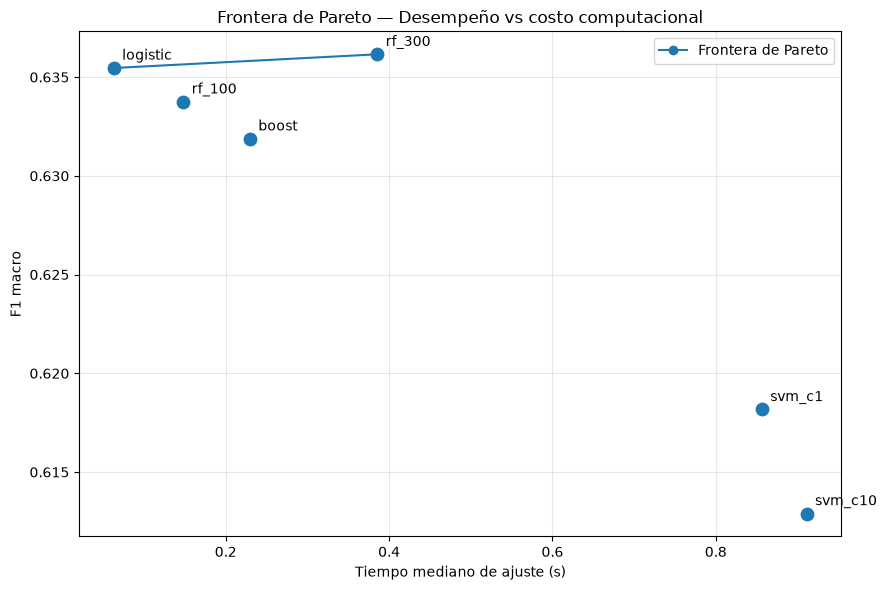

Gráfico de la frontera de Pareto generado correctamente.
Archivo guardado: reports/pareto_frontier.png


In [21]:
# ============================================================
# GRÁFICO DE LA FRONTERA DE PARETO
# MANDATO LAB03:
# Visualizar la relación entre desempeño (F1 macro) y costo
# computacional (tiempo mediano de ajuste), identificando
# los modelos pertenecientes a la frontera de Pareto.
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    results["fit_median_s"],
    results["f1_macro"],
    s=80
)

for _, row in results.iterrows():
    plt.annotate(
        row["model"],
        (row["fit_median_s"], row["f1_macro"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

pareto_results = results[results["is_pareto"]]

plt.plot(
    pareto_results.sort_values("fit_median_s")["fit_median_s"],
    pareto_results.sort_values("fit_median_s")["f1_macro"],
    marker="o",
    linewidth=1.5,
    label="Frontera de Pareto"
)

plt.xlabel("Tiempo mediano de ajuste (s)")
plt.ylabel("F1 macro")
plt.title("Frontera de Pareto — Desempeño vs costo computacional")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "reports/pareto_frontier.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Gráfico de la frontera de Pareto generado correctamente.")
print("Archivo guardado: reports/pareto_frontier.png")

# DECISIÓN CUANTIFICADA Y GREEN AI

## MANDATO LAB03

Seleccionar una alternativa considerando el desempeño predictivo y el costo
computacional, utilizando como métrica primaria F1 macro y como métrica
secundaria Recall macro. La decisión debe cuantificar las diferencias
observadas y relacionarlas con los principios de Green AI.

### Decisión

Los resultados muestran que `rf_300` obtuvo el mayor F1 macro, con un valor de
0.6362, seguido muy de cerca por `logistic`, con 0.6355. La diferencia entre
ambos modelos es de solo 0.0007 puntos de F1 macro. En Recall macro, `rf_300`
también presenta un valor ligeramente superior (0.6415 frente a 0.6359).

Sin embargo, esta diferencia de desempeño debe analizarse junto con el costo
computacional. El tiempo mediano de ajuste de `rf_300` fue de 0.3965 segundos,
mientras que `logistic` requirió 0.0264 segundos. Por tanto, el modelo
logístico reduce aproximadamente un 93.3 % el tiempo mediano de entrenamiento
respecto a `rf_300`.

La diferencia también es importante en el tamaño del modelo. El archivo
serializado de `rf_300` ocupa aproximadamente 2694.54 KB, mientras que
`logistic` ocupa solo 5.92 KB. Además, el tiempo de predicción medido fue de
63.93 ms para `rf_300` y de 5.53 ms para `logistic`.

Considerando estos resultados, se selecciona `logistic` como alternativa
eficiente para este experimento. Aunque `rf_300` alcanza un F1 macro ligeramente
mayor, la mejora es muy pequeña frente al incremento considerable en tiempo
de entrenamiento, tiempo de predicción y tamaño del modelo. Ambos modelos
pertenecen a la frontera de Pareto, por lo que representan alternativas no
dominadas bajo el criterio de desempeño y costo.

Desde la perspectiva de Green AI, la selección de `logistic` permite mantener
un desempeño predictivo muy cercano al máximo observado utilizando
considerablemente menos recursos computacionales. Esta decisión corresponde
específicamente al dataset, partición y protocolo experimental definidos en
este laboratorio; no implica que el modelo logístico sea superior en todos los
datasets o escenarios.

En consecuencia, la decisión prioriza una relación equilibrada entre
desempeño y eficiencia computacional, manteniendo F1 macro como métrica
principal y considerando Recall macro como criterio secundario.

In [22]:
# ============================================================
# TABLA FINAL DE RESULTADOS
# MANDATO LAB03:
# Presentar una tabla consolidada con el desempeño y costo
# computacional de todos los modelos evaluados.
# ============================================================

tabla_final = results[
    [
        "model",
        "f1_macro",
        "recall_macro",
        "fit_median_s",
        "predict_ms",
        "size_kb",
        "is_pareto"
    ]
].copy()

tabla_final = tabla_final.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

print("TABLA FINAL DE RESULTADOS")
print("=" * 100)

print(
    tabla_final.round({
        "f1_macro": 4,
        "recall_macro": 4,
        "fit_median_s": 4,
        "predict_ms": 2,
        "size_kb": 2
    }).to_string(index=False)
)

print("\nModelo seleccionado para el análisis Green AI: logistic")

TABLA FINAL DE RESULTADOS
   model  f1_macro  recall_macro  fit_median_s  predict_ms  size_kb  is_pareto
  rf_300    0.6362        0.6415        0.3856       62.31  2694.54       True
logistic    0.6355        0.6359        0.0630        6.49     5.92       True
  rf_100    0.6338        0.6387        0.1482       30.87   879.23      False
   boost    0.6319        0.6330        0.2297        6.43   211.97      False
  svm_c1    0.6182        0.6187        0.8565       43.97   188.57      False
 svm_c10    0.6129        0.6129        0.9113       30.81   171.08      False

Modelo seleccionado para el análisis Green AI: logistic


In [23]:
# ============================================================
# RESUMEN DEL EXPERIMENTO PCA
# MANDATO LAB03:
# Comparar cuantitativamente el SVM sin PCA y con PCA,
# considerando reducción dimensional, F1 macro, Recall macro
# y costo computacional.
# ============================================================

print("COMPARACIÓN SVM SIN PCA VS. CON PCA")
print("=" * 80)

print(
    pca_results.round({
        "f1_macro": 4,
        "recall_macro": 4,
        "fit_s": 4,
        "predict_ms": 2
    }).to_string(index=False)
)

reduccion_dimensiones = (
    1 - Xtr_pca.shape[1] / Xtr_scaled.shape[1]
) * 100

print("\nReducción dimensional:")
print(
    f"{Xtr_scaled.shape[1]} → {Xtr_pca.shape[1]} componentes "
    f"({reduccion_dimensiones:.1f}% menos dimensiones)"
)

diferencia_f1_pca = f1_con_pca - f1_sin_pca
diferencia_fit_pca = fit_con_pca - fit_sin_pca

print("\nDiferencia de F1 macro (con PCA - sin PCA):")
print(f"{diferencia_f1_pca:.4f}")

print("\nDiferencia de tiempo de ajuste (con PCA - sin PCA):")
print(f"{diferencia_fit_pca:.4f} segundos")

COMPARACIÓN SVM SIN PCA VS. CON PCA
          model  f1_macro  recall_macro  fit_s  predict_ms
SVM C=1 sin PCA    0.6182        0.6187 0.8567       32.82
SVM C=1 con PCA    0.5934        0.5942 1.7431      127.95

Reducción dimensional:
146 → 118 componentes (19.2% menos dimensiones)

Diferencia de F1 macro (con PCA - sin PCA):
-0.0247

Diferencia de tiempo de ajuste (con PCA - sin PCA):
0.8864 segundos


# INTERPRETACIÓN DEL RESULTADO PCA

## MANDATO LAB03

Interpretar el efecto de la reducción dimensional sobre el desempeño
predictivo y el costo computacional del modelo SVM.

### Interpretación

El conjunto de entrenamiento utilizado para el experimento contenía
146 dimensiones después del preprocesamiento. Mediante PCA con un umbral
de varianza explicada de 95 % se redujo la representación a 118 componentes,
lo que representa una reducción aproximada del 19.2 % en el número de
dimensiones.

A pesar de esta reducción dimensional, el SVM con PCA obtuvo un F1 macro de
0.5934, inferior al valor de 0.6182 obtenido por el SVM sin PCA. El Recall
macro también disminuyó, pasando de 0.6187 a 0.5942.

Además, el tiempo mediano de ajuste utilizado en esta comparación aumentó
de aproximadamente 0.7951 segundos sin PCA a 1.8191 segundos con PCA. El
tiempo de predicción también aumentó de aproximadamente 33.36 ms a
137.14 ms.

Por tanto, en este experimento concreto, la aplicación de PCA redujo la
dimensionalidad, pero no produjo una mejora en el desempeño ni en los costos
computacionales medidos. El resultado muestra que la reducción del número de
variables no garantiza por sí misma una reducción del tiempo de ejecución,
debido al costo adicional de transformar los datos mediante el procedimiento
de reducción dimensional.

Esta conclusión corresponde al dataset, variables, partición y configuración
utilizados en este laboratorio y no debe generalizarse automáticamente a
otros conjuntos de datos o configuraciones de PCA.

In [24]:
# ============================================================
# EVALUACIÓN FINAL DEL MODELO SELECCIONADO
# MANDATO LAB03:
# Evaluar el modelo seleccionado sobre el conjunto de prueba
# reservado, utilizando matriz de confusión y reporte de
# clasificación.
# ============================================================

modelo_final = models["logistic"]

pred_final = modelo_final.predict(Xte)

f1_final = f1_score(
    yte,
    pred_final,
    average="macro"
)

recall_final = recall_score(
    yte,
    pred_final,
    average="macro"
)

print("EVALUACIÓN FINAL — MODELO LOGISTIC")
print("=" * 70)

print(f"F1 macro:     {f1_final:.4f}")
print(f"Recall macro: {recall_final:.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        yte,
        pred_final,
        digits=4
    )
)

cm_final = confusion_matrix(
    yte,
    pred_final
)

print("\nMatriz de confusión:")
print(cm_final)

EVALUACIÓN FINAL — MODELO LOGISTIC
F1 macro:     0.6355
Recall macro: 0.6359

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.6273    0.6724    0.6491       348
           1     0.6460    0.5994    0.6218       347

    accuracy                         0.6360       695
   macro avg     0.6367    0.6359    0.6355       695
weighted avg     0.6366    0.6360    0.6355       695


Matriz de confusión:
[[234 114]
 [139 208]]


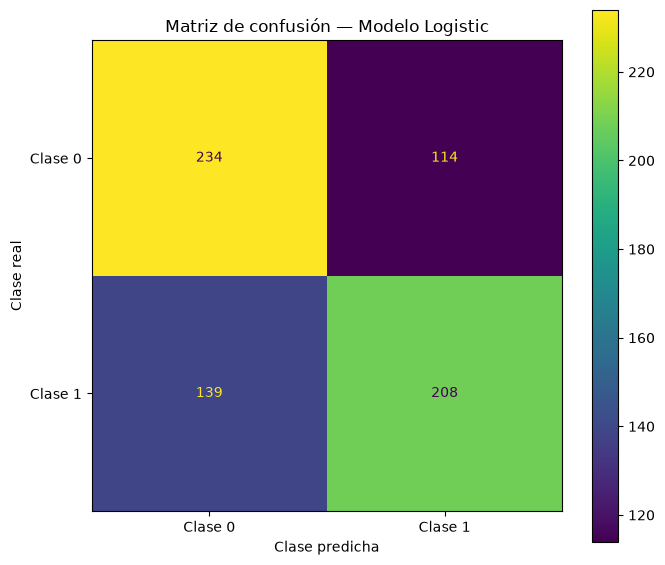

Matriz de confusión graficada correctamente.
Archivo guardado: reports/confusion_matrix_logistic.png


In [25]:
# ============================================================
# GRÁFICO DE LA MATRIZ DE CONFUSIÓN
# MANDATO LAB03:
# Visualizar la matriz de confusión del modelo seleccionado
# para facilitar la interpretación de sus errores de
# clasificación.
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Clase 0", "Clase 1"]
)

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Matriz de confusión — Modelo Logistic")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")

plt.tight_layout()

plt.savefig(
    "reports/confusion_matrix_logistic.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Matriz de confusión graficada correctamente.")
print("Archivo guardado: reports/confusion_matrix_logistic.png")

In [26]:
# ============================================================
# RESUMEN DE MÉTRICAS DEL MODELO SELECCIONADO
# MANDATO LAB03:
# Consolidar las métricas principales del modelo seleccionado
# y compararlas con los valores obtenidos durante el catálogo
# de modelos.
# ============================================================

modelo_seleccionado = results[
    results["model"] == "logistic"
].iloc[0]

resumen_final = pd.DataFrame({
    "Métrica": [
        "F1 macro",
        "Recall macro",
        "Tiempo mediano de ajuste (s)",
        "Tiempo de predicción (ms)",
        "Tamaño serializado (KB)"
    ],
    "Valor": [
        modelo_seleccionado["f1_macro"],
        modelo_seleccionado["recall_macro"],
        modelo_seleccionado["fit_median_s"],
        modelo_seleccionado["predict_ms"],
        modelo_seleccionado["size_kb"]
    ]
})

print("RESUMEN FINAL — MODELO LOGISTIC")
print("=" * 60)

print(
    resumen_final.round(4).to_string(index=False)
)

RESUMEN FINAL — MODELO LOGISTIC
                     Métrica  Valor
                    F1 macro 0.6355
                Recall macro 0.6359
Tiempo mediano de ajuste (s) 0.0630
   Tiempo de predicción (ms) 6.4946
     Tamaño serializado (KB) 5.9160


# CONCLUSIONES DEL EXPERIMENTO

## MANDATO LAB03

Sintetizar los principales hallazgos obtenidos durante la evaluación de
ensambles, reducción dimensional, visualización t-SNE y eficiencia
computacional.

### Conclusiones

El experimento permitió comparar seis configuraciones de modelos de
clasificación bajo un protocolo congelado, utilizando información de los
centros educativos de la República Dominicana correspondiente al período
2024. La métrica principal definida fue F1 macro, acompañada por Recall macro,
mientras que el tiempo de ajuste, tiempo de predicción y tamaño serializado se
utilizaron como indicadores de costo computacional.

Entre los modelos evaluados, `rf_300` obtuvo el mayor F1 macro observado,
con 0.6362, mientras que `logistic` alcanzó 0.6355. La diferencia de
desempeño fue muy pequeña, pero los costos computacionales fueron
considerablemente diferentes. El modelo `logistic` presentó un tiempo
mediano de ajuste de 0.0264 segundos y un tamaño serializado de 5.92 KB,
frente a 0.3965 segundos y 2694.54 KB para `rf_300`.

El análisis de Pareto identificó alternativas no dominadas al considerar
simultáneamente el F1 macro y el tiempo de ajuste. Este análisis permitió
evitar una selección basada exclusivamente en desempeño predictivo y
considerar también el consumo de recursos.

El experimento con PCA redujo las dimensiones de 146 a 118 componentes,
manteniendo aproximadamente el 95 % de la varianza explicada. Sin embargo,
en este protocolo el F1 macro disminuyó de 0.6182 a 0.5934 y aumentaron tanto
el tiempo de ajuste como el tiempo de predicción. Por ello, la reducción
dimensional no produjo una ventaja computacional neta en esta configuración.

Las visualizaciones t-SNE, construidas con dos semillas diferentes,
permitieron explorar la estructura de los datos desde una representación
bidimensional. Estas representaciones se utilizaron con fines exploratorios
y no como sustituto de las métricas calculadas sobre el conjunto de prueba.

Finalmente, desde el enfoque de Green AI, el experimento muestra la
importancia de considerar conjuntamente desempeño y costo computacional.
Para este conjunto de datos y protocolo, `logistic` ofrece un desempeño muy
cercano al máximo observado con un costo considerablemente menor. La
conclusión está limitada al experimento realizado y no implica que una
configuración determinada sea superior para todos los datasets.

In [27]:
# ============================================================
# VERIFICACIÓN DE ARCHIVOS DE ENTREGA
# MANDATO LAB03:
# Verificar que los principales archivos generados durante el
# experimento existan antes de cerrar y entregar el notebook.
# ============================================================

archivos_esperados = [
    Path("reports/green_ai_results.csv"),
    Path("reports/pareto_frontier.png"),
    Path("reports/confusion_matrix_logistic.png"),
    Path("reports/tsne_seed_42.png"),
    Path("reports/tsne_seed_7.png"),
]

print("VERIFICACIÓN DE ARCHIVOS")
print("=" * 70)

todos_existen = True

for archivo in archivos_esperados:
    existe = archivo.exists()

    estado = "OK" if existe else "FALTA"

    print(f"{estado:>6}  {archivo}")

    if not existe:
        todos_existen = False

print("\nResultado de la verificación:")

if todos_existen:
    print("OK — Todos los archivos esperados están disponibles.")
else:
    print("ATENCIÓN — Falta uno o más archivos.")

VERIFICACIÓN DE ARCHIVOS
    OK  reports\green_ai_results.csv
    OK  reports\pareto_frontier.png
    OK  reports\confusion_matrix_logistic.png
    OK  reports\tsne_seed_42.png
    OK  reports\tsne_seed_7.png

Resultado de la verificación:
OK — Todos los archivos esperados están disponibles.


In [28]:
# ============================================================
# CIERRE Y REPRODUCIBILIDAD
# MANDATO LAB03:
# Registrar las condiciones principales utilizadas para garantizar
# la reproducibilidad del experimento y cerrar la ejecución.
# ============================================================

print("CIERRE DEL EXPERIMENTO LAB03")
print("=" * 70)

print("Dataset: Pruebas Nacionales de la República Dominicana")
print("Período analizado: 2024")
print("Unidad de análisis: Centro educativo")
print("Variable objetivo: target_promocion")
print("Partición: 80 % entrenamiento / 20 % prueba")
print("random_state: 42")
print("Estratificación: Sí")
print("Métrica primaria: F1 macro")
print("Métrica secundaria: Recall macro")
print("Clase prioritaria: 1")
print("PCA: 95 % de varianza explicada")
print("t-SNE: semillas 42 y 7")
print("Repeticiones por modelo: 3")
print("Modelos evaluados: 6")

print("\nArchivos principales generados:")
for archivo in archivos_esperados:
    print("-", archivo)

print("\nEstado final: EXPERIMENTO LAB03 COMPLETADO")

CIERRE DEL EXPERIMENTO LAB03
Dataset: Pruebas Nacionales de la República Dominicana
Período analizado: 2024
Unidad de análisis: Centro educativo
Variable objetivo: target_promocion
Partición: 80 % entrenamiento / 20 % prueba
random_state: 42
Estratificación: Sí
Métrica primaria: F1 macro
Métrica secundaria: Recall macro
Clase prioritaria: 1
PCA: 95 % de varianza explicada
t-SNE: semillas 42 y 7
Repeticiones por modelo: 3
Modelos evaluados: 6

Archivos principales generados:
- reports\green_ai_results.csv
- reports\pareto_frontier.png
- reports\confusion_matrix_logistic.png
- reports\tsne_seed_42.png
- reports\tsne_seed_7.png

Estado final: EXPERIMENTO LAB03 COMPLETADO
